In [ ]:
# instalace dash
!pip install dash

In [ ]:
# import knihoven
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import threading
from dash import Dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
from google.colab import output
from google.colab import drive

In [ ]:
# připojení disku
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# vytvoření dataframe
df_covid = pd.read_csv('/content/drive/MyDrive/DATA_ANALYST/project_1_python.csv')
df_covid.head()

,index,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
0,0,AFG,Asia,Afghanistan,2020-02-24,5.0,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
1,1,AFG,Asia,Afghanistan,2020-02-25,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
2,2,AFG,Asia,Afghanistan,2020-02-26,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
3,3,AFG,Asia,Afghanistan,2020-02-27,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0
4,4,AFG,Asia,Afghanistan,2020-02-28,5.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,39835428.0,18.6,1803.987,64.83,33.0,65.0


In [ ]:
# kontrola úplnosti dat
print(df_covid.isnull().sum())


index                           0
iso_code                        0
continent                       0
location                        0
date                            0
total_cases                  6984
new_cases                    7265
total_deaths                25154
new_deaths                  25382
hosp_patients              153325
total_tests                102151
new_tests                  105968
tests_per_case              87877
total_vaccinations         134111
people_vaccinated          136626
people_fully_vaccinated    138953
total_boosters             160611
new_vaccinations           143537
population                      0
median_age                  21151
gdp_per_capita              22483
life_expectancy              1051
latitude                        0
longitude                       0
dtype: int64


In [ ]:
# seřazení prvních 10 zemí podle populace
largest_population = df_covid.sort_values(by='population', ascending=False).drop_duplicates(subset='location').head(10)
largest_population


,index,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,hosp_patients,...,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,population,median_age,gdp_per_capita,life_expectancy,latitude,longitude
33501,35163,CHN,Asia,China,2020-01-24,916.0,277.0,26.0,8.0,NaN,...,NaN,NaN,NaN,NaN,1.444216e+09,38.7,15308.712,76.91,35.0,105.0
75440,77932,IND,Asia,India,2022-06-18,43296692.0,12899.0,524855.0,15.0,NaN,...,1.014572e+09,905029095.0,39667541.0,1623721.0,1.393409e+09,28.2,6426.674,69.66,20.0,77.0
171764,180195,USA,North America,United States,2022-04-06,80255299.0,40947.0,986523.0,1130.0,10421.0,...,2.561483e+08,219199647.0,102936360.0,573785.0,3.329151e+08,38.3,54225.446,78.86,38.0,-97.0
75443,77935,IDN,Asia,Indonesia,2020-03-04,2.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.763618e+08,29.3,11188.744,71.72,-5.0,120.0
123818,127961,PAK,Asia,Pakistan,2022-05-25,1530066.0,76.0,30379.0,0.0,NaN,...,1.349438e+08,123024964.0,7903887.0,103071.0,2.251999e+08,23.5,5034.708,67.27,30.0,70.0
22644,23474,BRA,South America,Brazil,2022-06-14,31541479.0,44441.0,668354.0,174.0,NaN,...,1.843210e+08,168113218.0,101097404.0,460775.0,2.139934e+08,33.5,14103.452,75.88,-10.0,-55.0
118136,122279,NGA,Africa,Nigeria,2020-03-01,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.114007e+08,18.1,5338.454,54.69,10.0,8.0
13035,13035,BGD,Asia,Bangladesh,2021-03-15,559168.0,1773.0,8571.0,26.0,NaN,...,NaN,NaN,NaN,NaN,1.663035e+08,27.5,3523.984,72.59,24.0,90.0
134054,138801,RUS,Europe,Russia,2021-09-26,7313112.0,22015.0,200245.0,795.0,NaN,...,4.759499e+07,41706138.0,662363.0,96374.0,1.459120e+08,39.6,24765.954,72.58,60.0,100.0
103850,107179,MEX,North America,Mexico,2020-01-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.302622e+08,29.3,17336.469,75.05,23.0,-102.0


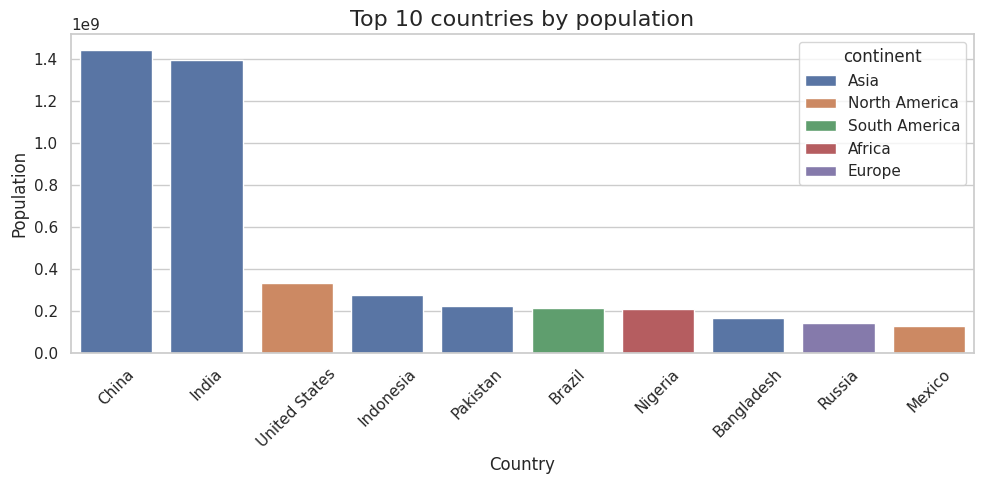

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# nastavení stylu
sns.set_theme(style='whitegrid')

# vytvoření figure
plt.figure(figsize=(10, 5))

# vykreslení grafu
sns.barplot(
    data=largest_population,
    x='location',
    y='population',
    hue='continent'
)

# úpravy grafu
plt.title("Top 10 countries by population", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.tight_layout()

# zobrazení grafu
plt.show()


In [ ]:
# population vs. life expentancy
fig = px.scatter(
    data_frame=df_covid,
    title='Population vs. life expectancy',
    x='population',
    y='life_expectancy',
    color='continent',
    color_discrete_sequence=px.colors.qualitative.Dark2,
    size='population',
    hover_name='location',
    hover_data='life_expectancy',
    log_x=True
    )

# zlepšení viditelnosti
fig.update_traces(marker=dict(opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))

fig.show()

In [ ]:
# new cases in CZR and USA

# filtrování dat
countries_of_interest = ['Czechia', 'United States']
df_filtered = df_covid[df_covid['location'].isin(countries_of_interest)]

fig = px.line(
    data_frame=df_filtered,
    title='New cases over time in Czechia and USA',
    x='date',
    y='new_cases',
    color='location',
    color_discrete_sequence=px.colors.qualitative.D3
    )

fig.show()

In [ ]:
# agregace podle země
df_world = (
    df_covid.groupby(["location", "continent", "latitude", "longitude"])
    .agg({"total_cases": "max", "population": "max"})
    .reset_index()
)

# podíl případů na populaci
df_world["cases_per_capita"] = df_world["total_cases"] / df_world["population"]

# odstranění řádků s NaN, nulami, nebo nekonečnými hodnotami
df_world = df_world.dropna(subset=["cases_per_capita", "latitude", "longitude", "continent"])
df_world = df_world[df_world["cases_per_capita"] > 0]
df_world = df_world[df_world["population"] > 0]

# vytvoření scatter_mapbox
fig = px.scatter_mapbox(
    df_world,
    lat="latitude",
    lon="longitude",
    size="cases_per_capita",
    color="continent",
    hover_name="location",
    hover_data={
        "total_cases": True,
        "cases_per_capita": False,
        "latitude": False,
        "longitude": False
    },
    size_max=40,
    zoom=1,
       center=dict(lat=0, lon=0),
    title="COVID-19 Cases by Country and Continent",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    mapbox=dict(
        style="carto-darkmatter",
        center=dict(lat=0, lon=0),
        zoom=1,
        bounds=dict(
            west=-180,   # západní hranice
            south=-60,   # jižní hranice
            east=180,    # východní hranice
            north= 85    # severní hranice
        )
    ),
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [ ]:
# alternativa - chloropleth, barvy podle zemí, cases per capita

# výběr posledního záznamu pro každou zemi, aby nebyly duplicity
df_unique = df_covid.drop_duplicates(subset=['iso_code'], keep='last')
df_unique['cases_ratio'] = df_unique['total_cases'] / df_unique['population']

# odstranění řádků s NaN, nulami, nebo nekonečnými hodnotami
df_unique = df_unique.dropna(subset=["cases_ratio", "latitude", "longitude", "continent"])
df_unique = df_unique[df_unique["cases_ratio"] > 0]
df_unique = df_unique[df_unique["population"] > 0]

fig = px.choropleth(
    df_unique,
    locations='iso_code',
    locationmode='ISO-3',
    color='cases_ratio',
    hover_name='location',
    color_continuous_scale='Reds',
    title='Cases of COVID-19 per capita'
)

fig.show()


/tmp/ipykernel_213/577921653.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# dashboard #1

# inicializace dash aplikace
app = Dash(__name__)
server = app.server  # pro případný deploy

# seznam zemí
countries = sorted(df_covid['location'].dropna().unique())

# layout aplikace
app.layout = html.Div([
    # dynamický titulek
    html.H1(id='dynamic-title', style={'textAlign': 'center'}),

    # dropdown pro výběr země
    html.Label('Select a country:', style={'fontWeight': 'bold'}),
    dcc.Dropdown(
        id='country-dropdown',
        options=[{'label': country, 'value': country} for country in countries],
        value=countries[0],  # výchozí hodnota
        clearable=False
    ),

    # dva grafy vedle sebe
    html.Div([
        dcc.Graph(id='graph-1', style={'width': '48%', 'display': 'inline-block'}),
        dcc.Graph(id='graph-2', style={'width': '48%', 'display': 'inline-block'})
    ])
])

# callback pro aktualizaci titulku a grafů
@app.callback(
    Output('dynamic-title', 'children'),
    Output('graph-1', 'figure'),
    Output('graph-2', 'figure'),
    Input('country-dropdown', 'value')
)
def update_dashboard(selected_country):
    # dynamický titulek
    title = f'Cumulative number of positive cases in {selected_country}'

     # filtrování dat pro vybranou zemi
    df_country = df_covid[df_covid['location'] == selected_country]

    # graf 1 – případy
    fig_cases = px.line(
        df_country,
        x='date',
        y='total_cases',
        title='Cumulative COVID-19 Cases Over Time'
    )

    # Graf 2 – úmrtí
    fig_deaths = px.line(
        df_country,
        x='date',
        y='total_deaths',
        title='Cumulative COVID-19 Deaths Over Time'
    )

    # návrat titulku a obou grafů
    return title, fig_cases, fig_deaths

# spuštění v Colabu
def run_dash():
    app.run(debug=False, use_reloader=False)

thread = threading.Thread(target=run_dash)
thread.start()

output.serve_kernel_port_as_iframe(8050, height=800)


Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



<IPython.core.display.Javascript object>

In [ ]:
# dashboard #2

# filtr posledního záznamu za každou zemi
df_unique = df_covid.sort_values('date').drop_duplicates(subset='iso_code', keep='last')

#inicializace dash aplikace
app = Dash(__name__)
server = app.server  # pro případný deploy

#seznam kontinentů a metrik
continents = sorted(df_covid['continent'].dropna().unique())
metrics = ['total_cases', 'total_deaths', 'total_tests', 'total_vaccinations', 'people_vaccinated']

#layout aplikace
app.layout = html.Div([
    html.H1(id='dynamic-title', style={'textAlign': 'center'}),

    html.Label('Select continent:', style={'fontWeight': 'bold'}),
    dcc.Dropdown(
        id='continent-dropdown',
        options=[{'label': c, 'value': c} for c in continents],
        value=continents[0],
        clearable=False
    ),

    html.Label('Select metric:', style={'fontWeight': 'bold', 'marginTop': '10px'}),
    dcc.Dropdown(
        id='metric-dropdown',
        options=[{'label': m.replace('_', ' ').capitalize(), 'value': m} for m in metrics],
        value=metrics[0],
        clearable=False
    ),

    dcc.Graph(id='map-graph')
])

#callback
@app.callback(
    Output('dynamic-title', 'children'),
    Output('map-graph', 'figure'),
    Input('continent-dropdown', 'value'),
    Input('metric-dropdown', 'value')
)

def update_dashboard(selected_continent, selected_metric):
    # titulek
    title = f'COVID-19 – {selected_metric.replace("_", " ").capitalize()} in {selected_continent}'

    # Filtrování podle kontinentu
    df_filtered = df_unique[df_unique['continent'] == selected_continent]

    # Odebrání řádků bez dat pro danou metriku
    df_filtered = df_filtered[df_filtered[selected_metric].notna()]

    # Vytvoření mapy
    fig = px.scatter_mapbox(
        df_filtered,
        lat="latitude",
        lon="longitude",
        size=selected_metric,
        hover_name="location",
        hover_data={selected_metric: True, 'latitude': False, 'longitude': False},
        size_max=40,
        zoom=2,
        mapbox_style="carto-darkmatter",
        title=""
    )

    return title, fig

#spuštění v colabu
def run_dash():
  app.run(debug=False, use_reloader=False)

thread = threading.Thread(target=run_dash)
thread.start()

output.serve_kernel_port_as_iframe(8050, height=800)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit


Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



<IPython.core.display.Javascript object>

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
# dashboard #3

# nový dataframe s posledním záznamem pro každou zemi
df_unique = df_covid.sort_values('date').drop_duplicates(subset='iso_code', keep='last')

# přidání sloupce s relativním počtem vakcinací
df_unique['vaccination_ratio'] = df_unique['total_vaccinations'] / df_unique['population']

# odstranění řádků s chybějícími hodnotami
df_cleaned = df_unique.dropna(subset=['total_vaccinations', 'vaccination_ratio', 'location'])

# inicializace aplikace
app = Dash(__name__)
server = app.server

# volby pro dropdown
available_numbers = [5, 10, 15, 20]

# layout aplikace
app.layout = html.Div([
    html.H1(id='title', style={'textAlign': 'center'}),

    html.Label('Select number of countries:', style={'fontWeight': 'bold'}),
    dcc.Dropdown(
        id='number-dropdown',
        options=[{'label': n, 'value': n} for n in available_numbers],
        value=5,
        clearable=False
    ),

    html.Div([
        dcc.Graph(id='graph-1', style={'width': '48%', 'display': 'inline-block'}),
        dcc.Graph(id='graph-2', style={'width': '48%', 'display': 'inline-block'})
    ])
])

# callback
@app.callback(
    Output('title', 'children'),
    Output('graph-1', 'figure'),
    Output('graph-2', 'figure'),
    Input('number-dropdown', 'value')
)
def update_dashboard(selected_number):
    # pojistka, pokud je k dispozici méně dat než výběr
    selected_number = min(selected_number, len(df_cleaned))

    # titulek
    title = f'Top {selected_number} countries by total vaccinations and vaccination ratio'

    # top země
    top_vaccinations = df_cleaned.nlargest(selected_number, 'total_vaccinations')
    top_ratio = df_cleaned.nlargest(selected_number, 'vaccination_ratio')

    # graf 1
    fig_1 = px.bar(
        top_vaccinations,
        x='location',
        y='total_vaccinations',
        title='Total vaccinations (absolute)',
        labels={'location': 'Country', 'total_vaccinations': 'Total Vaccinations'}
    )

    # graf 2
    fig_2 = px.bar(
        top_ratio,
        x='location',
        y='vaccination_ratio',
        title='Total vaccinations per capita (ratio)',
        labels={'location': 'Country', 'vaccination_ratio': 'Vaccination Ratio'}
    )

    return title, fig_1, fig_2

# spuštění v Colabu
def run_dash():
    app.run(debug=False, use_reloader=False)

thread = threading.Thread(target=run_dash)
thread.start()
output.serve_kernel_port_as_iframe(8050, height=800)


Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'


<IPython.core.display.Javascript object>

 * Debug mode: off


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.
